In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
# Check data types and missing values
df.info()

# Check first 5 rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
df['Churn Reason'].value_counts(dropna=False)


Churn Reason
NaN                                          5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Limited range of services                      44
Lack of affordable download/upload speed       44
Long distance charges                          44
Poor expertise of phone support                20
Poor expertise of online support     

In [9]:
# 1 = churned, 0 = not churned
df['Churn'] = df['Churn Reason'].notnull().astype(int)


In [10]:
cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
    'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
    'Online Backup', 'Device Protection', 'Monthly Charges', 'CLTV', 'Churn'
]

df_model = df[cols]
df_model.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Monthly Charges,CLTV,Churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,53.85,3239,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,70.70,2701,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,99.65,5372,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,104.80,5003,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,103.70,5340,1


In [11]:
from sklearn.preprocessing import LabelEncoder

# Copy the dataset to avoid warnings
df_model_encoded = df_model.copy()

# Encode object (text) columns
le = LabelEncoder()
for col in df_model_encoded.select_dtypes(include='object').columns:
    df_model_encoded[col] = le.fit_transform(df_model_encoded[col])

# Check first 5 rows
df_model_encoded.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Monthly Charges,CLTV,Churn
0,1,0,0,0,2,1,0,0,2,2,0,53.85,3239,1
1,0,0,0,1,2,1,0,1,0,0,0,70.70,2701,1
2,0,0,0,1,8,1,2,1,0,0,2,99.65,5372,1
3,0,0,1,1,28,1,2,1,0,0,2,104.80,5003,1
4,1,0,0,1,49,1,2,1,0,2,2,103.70,5340,1


In [12]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df_model_encoded.drop('Churn', axis=1)
y = df_model_encoded['Churn']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5634, 13)
X_test shape: (1409, 13)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
model = RandomForestClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Accuracy & report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7892122072391767
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [14]:
import pandas as pd

# Feature importance
importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp)


              Feature  Importance
4       Tenure Months    0.257666
11    Monthly Charges    0.229967
12               CLTV    0.212701
8     Online Security    0.060493
7    Internet Service    0.040652
3          Dependents    0.040086
9       Online Backup    0.030286
10  Device Protection    0.026976
0              Gender    0.026516
2             Partner    0.025074
6      Multiple Lines    0.022439
1      Senior Citizen    0.021854
5       Phone Service    0.005290


Accuracy: 0.7892122072391767
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409

              Feature  Importance
4       Tenure Months    0.257666
11    Monthly Charges    0.229967
12               CLTV    0.212701
8     Online Security    0.060493
7    Internet Service    0.040652
3          Dependents    0.040086
9       Online Backup    0.030286
10  Device Protection    0.026976
0              Gender    0.026516
2             Partner    0.025074
6      Multiple Lines    0.022439
1      Senior Citizen    0.021854
5       Phone Service    0.005290


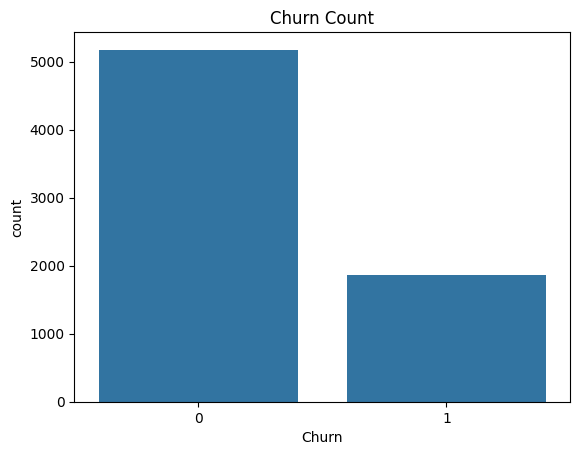

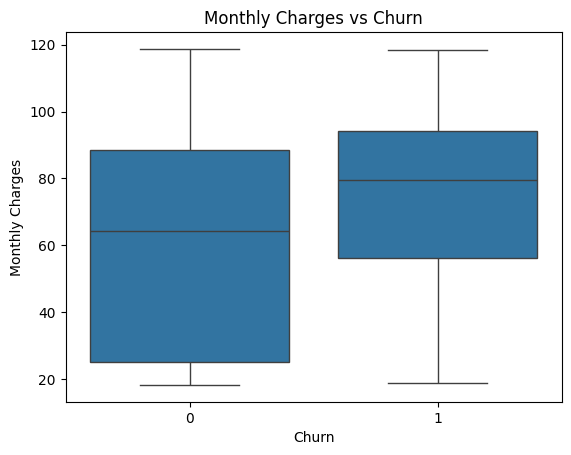

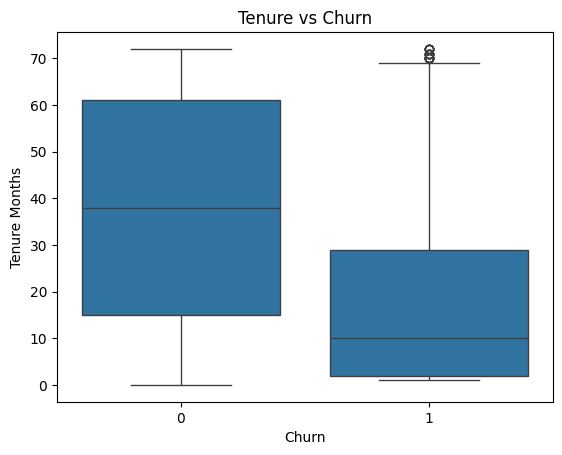

In [16]:

# 📝 churn_analysis.ipynb (full code for your notebook)

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_excel('../data/Telco_customer_churn.xlsx')

# Create Churn column
df['Churn'] = df['Churn Reason'].notnull().astype(int)

# Select relevant columns
cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
    'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
    'Online Backup', 'Device Protection', 'Monthly Charges', 'CLTV', 'Churn'
]
df_model = df[cols]

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
df_model_encoded = df_model.copy()
le = LabelEncoder()
for col in df_model_encoded.select_dtypes(include='object').columns:
    df_model_encoded[col] = le.fit_transform(df_model_encoded[col])

# Train-test split
from sklearn.model_selection import train_test_split
X = df_model_encoded.drop('Churn', axis=1)
y = df_model_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp)

# EDA Plots
sns.countplot(x='Churn', data=df)
plt.title('Churn Count')
plt.show()

sns.boxplot(x='Churn', y='Monthly Charges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

sns.boxplot(x='Churn', y='Tenure Months', data=df)
plt.title('Tenure vs Churn')
plt.show()
